In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile

DATA = Path("~/dati/walnut/Walnut1/Projections/tubeV1").expanduser()
print(sorted(p.name for p in DATA.iterdir())[:10])

['data settings XRE.txt', 'di000000.tif', 'io000000.tif', 'io000001.tif', 'scan settings.txt', 'scan_000000.tif', 'scan_000001.tif', 'scan_000002.tif', 'scan_000003.tif', 'scan_000004.tif']


In [2]:
dark = tifffile.imread(DATA / "di000000.tif")
flat0 = tifffile.imread(DATA / "io000000.tif")
flat1 = tifffile.imread(DATA / "io000001.tif")
proj = tifffile.imread(DATA / "scan_000000.tif")

for name, img in [("dark", dark), ("flat0", flat0), ("flat1", flat1), ("proj", proj)]:
    print(f"{name:6s} shape={img.shape} dtype={img.dtype} min={img.min()} max={img.max()} mean={img.mean():.1f}")

<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')
<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')
<TiffTag.fromfile> raised TiffFileError('<tifffile.TiffTag 320 @1493217> invalid value offset 0')


dark   shape=(768, 972) dtype=uint16 min=304 max=417 mean=342.7
flat0  shape=(768, 972) dtype=uint16 min=6340 max=14301 mean=11288.8
flat1  shape=(768, 972) dtype=uint16 min=6387 max=14394 mean=11359.4
proj   shape=(768, 972) dtype=uint16 min=3976 max=13721 mean=8345.8


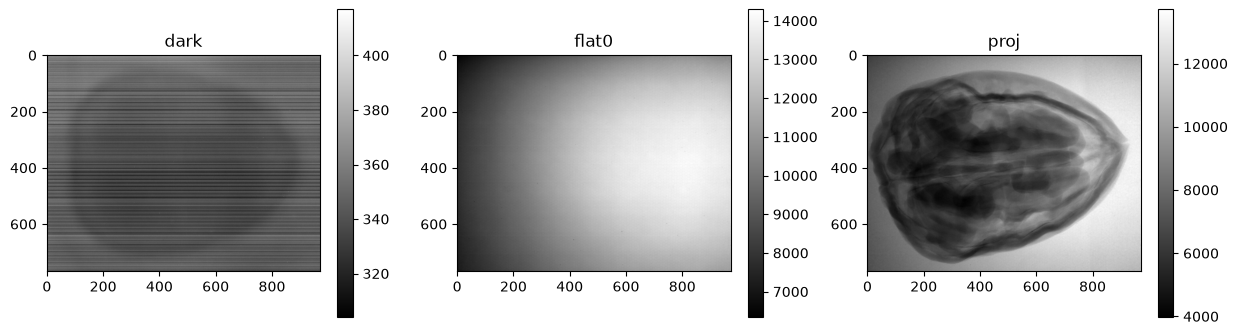

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, img) in zip(axes, [("dark", dark), ("flat0", flat0), ("proj", proj)]):
    im = ax.imshow(img, cmap="gray")
    ax.set_title(name)
    fig.colorbar(im, ax=ax)
plt.show()

## Observations (tubeV1, Walnut1)

- **Shape**: (768, 972), transposed w.r.t. the paper (972 rows × 768 cols). Readout-column axis to be determined.
- **Range**: flat max 14394 ADU = 88% of 14-bit full scale (16383) → no saturation, ~2000 ADU headroom.
- **Dark**: 304–417 ADU, mean 343. The walnut outline is visible although the source was off → residual image from the previous exposure (detector lag). Out of scope, documented.
- **Flat**: 6340–14301 ADU, non-uniform by a factor ~2.3 → mostly beam profile (cone geometry, distance, anode heel effect), plus per-pixel gain. This is what flat-field correction removes.
- **Flat drift**: mean(flat1) − mean(flat0) = +70.6 ADU (+0.6%) over one orbit → to quantify spatially in milestone 3.


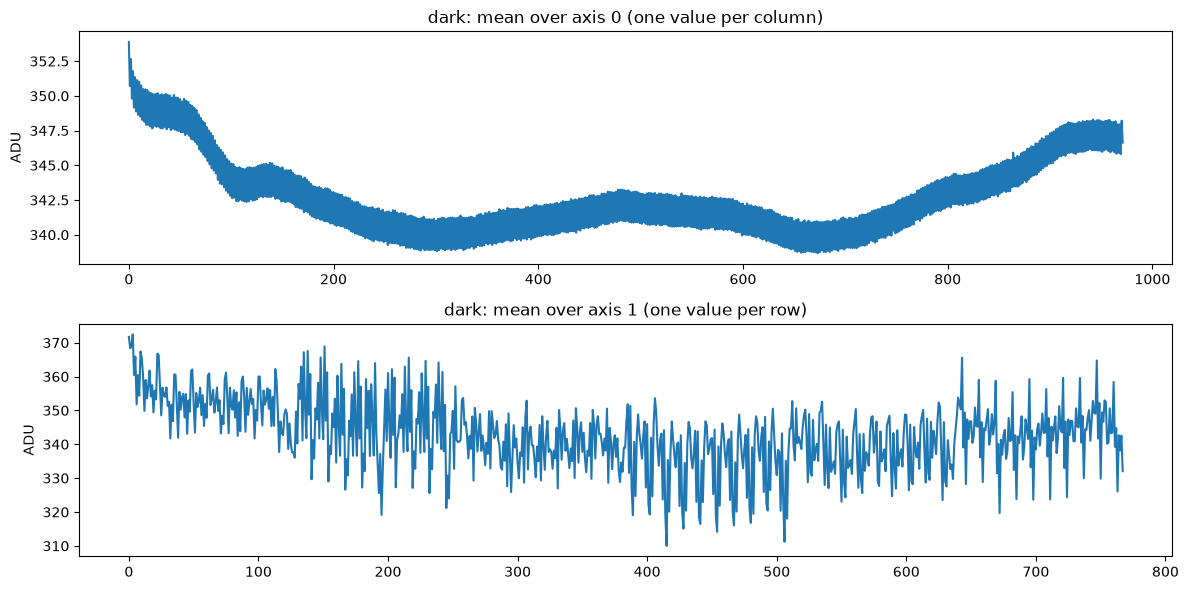

std of column means: 2.89 ADU
std of row means:    10.48 ADU
std of whole dark:   11.14 ADU


In [4]:
dark_f = dark.astype(np.float64)

col_mean = dark_f.mean(axis=0)   # one value per column (length 972)
row_mean = dark_f.mean(axis=1)   # one value per row (length 768)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(col_mean)
axes[0].set_title("dark: mean over axis 0 (one value per column)")
axes[1].plot(row_mean)
axes[1].set_title("dark: mean over axis 1 (one value per row)")
for ax in axes:
    ax.set_ylabel("ADU")
plt.tight_layout()
plt.show()

print(f"std of column means: {col_mean.std():.2f} ADU")
print(f"std of row means:    {row_mean.std():.2f} ADU")
print(f"std of whole dark:   {dark_f.std():.2f} ADU")

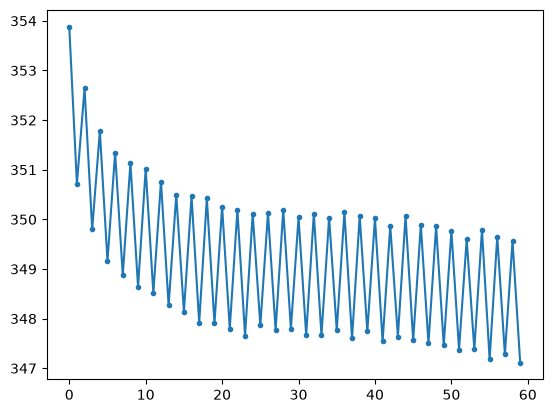

In [5]:
plt.plot(col_mean[:60], ".-")

### 1.2 Dark structure
- **Readout stripes are per row**: the dark mean of each image row jumps by tens of ADU from row to row (std 10.5 ADU) → horizontal stripes in our orientation, vertical in the paper, which displays the image transposed.
- **Column offset dominates the dark**: 88% of dark variance (110 of 124 ADU²). Residual per-pixel variability ≈ 2.4 ADU; with a single dark, pixel offset and temporal read noise cannot be separated.
- **Across columns**: slow variation of ~14 ADU, lower in the centre (consistent with the walnut residual image), plus a fast 1–2 ADU alternation between neighbours (to check: even/odd pattern).
- **Even/odd pattern along axis 1**: even indices ~2 ADU higher than odd ones, regular across the axis (hypothesis: separate readout channels). To reproduce in the simulator as a period-2 offset.
- **Edge effect**: the first ~20 columns are up to ~4 ADU higher.

min F0 after dark subtraction: 5974 ADU
ratio: mean 1.00640, std 0.00215
smoothed ratio (inner): min 1.00349, max 1.01013


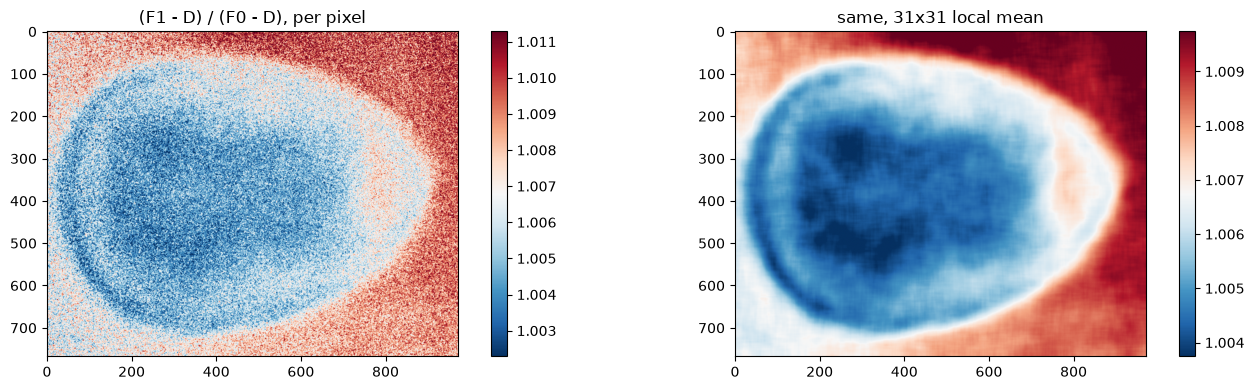

In [6]:
from scipy import ndimage

F0 = flat0.astype(np.float64) - dark_f
F1 = flat1.astype(np.float64) - dark_f
print(f"min F0 after dark subtraction: {F0.min():.0f} ADU")  # must be well above 0

ratio = F1 / F0
print(f"ratio: mean {ratio.mean():.5f}, std {ratio.std():.5f}")

ratio_smooth = ndimage.uniform_filter(ratio, size=31)
inner = ratio_smooth[31:-31, 31:-31]  # drop borders affected by the filter
print(f"smoothed ratio (inner): min {inner.min():.5f}, max {inner.max():.5f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lo, hi = np.percentile(ratio, [1, 99])
im0 = axes[0].imshow(ratio, cmap="RdBu_r", vmin=lo, vmax=hi)
axes[0].set_title("(F1 - D) / (F0 - D), per pixel")
fig.colorbar(im0, ax=axes[0])
lo_s, hi_s = np.percentile(inner, [1, 99])
im1 = axes[1].imshow(ratio_smooth, cmap="RdBu_r", vmin=lo_s, vmax=hi_s)
axes[1].set_title("same, 31x31 local mean")
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

### 1.3 Flat drift during the orbit
- **Global drift**: mean of (F1 − D)/(F0 − D) = 1.0064 → the flat increased by 0.64% between start and end of the orbit.
- **Spatial component**: not uniform. The 31×31 local mean of the ratio ranges from 1.0035 behind the walnut silhouette to 1.0101 outside it (~0.66% peak-to-peak, same order as the global part). The pattern has the shape of the walnut.
- **Interpretation**: an object-shaped change can only come from detector memory of the scan. Pixels outside the walnut received more exposure and show more residual signal (lag), the same effect visible in the dark.
- **Consequence for milestone 3**: no single flat represents the whole scan. Flat-field correction carries an object-dependent residual error of order 0.5%. Lag stays out of scope: not corrected, but quantified as a limitation.

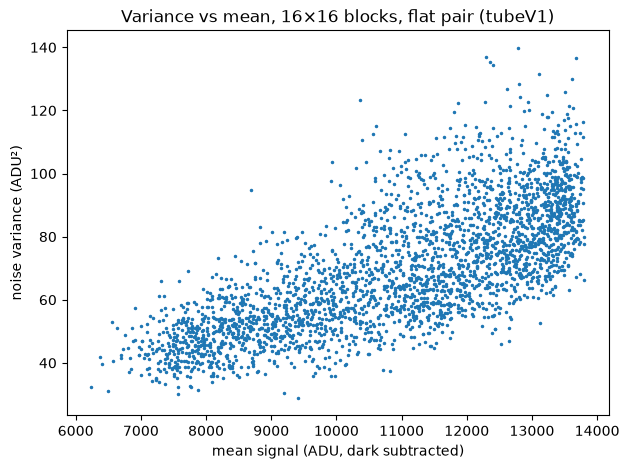

slope K ≈ 0.0073 ADU per quantum, intercept ≈ -10.9 ADU²


In [7]:
B = 16  # block size in pixels
n_rows, n_cols = F0.shape  # F0, F1: dark-subtracted float flats from step 3

means, variances = [], []
for r in range(0, n_rows - B + 1, B):
    for c in range(0, n_cols - B + 1, B):
        f0 = F0[r:r+B, c:c+B]
        f1 = F1[r:r+B, c:c+B]
        means.append(0.5 * (f0.mean() + f1.mean()))
        variances.append(np.var(f1 - f0) / 2)

means = np.array(means)
variances = np.array(variances)

plt.figure(figsize=(7, 5))
plt.plot(means, variances, ".", markersize=3)
plt.xlabel("mean signal (ADU, dark subtracted)")
plt.ylabel("noise variance (ADU²)")
plt.title("Variance vs mean, 16×16 blocks, flat pair (tubeV1)")
plt.show()

slope, intercept = np.polyfit(means, variances, 1)
print(f"slope K ≈ {slope:.4f} ADU per quantum, intercept ≈ {intercept:.1f} ADU²")

### 1.4 Noise: variance vs mean (flat pair)
- **Method**: var(F1 − F0)/2 in 16×16 blocks vs block mean of dark-subtracted flats. The difference removes everything fixed (beam profile, pixel gain, dark), leaving only noise.
- **Result**: variance grows with signal, from ~45 ADU² at 7000 ADU to ~90 ADU² at 13500 ADU → signal-dependent noise, consistent with counting statistics. Linear fit: slope 0.0073 ADU per quantum (effective), intercept −10.9 ADU².
- **Caveats**: the negative intercept is unphysical (data cover only 6000–14000 ADU, so extrapolation to zero is unreliable). Scatter is larger than expected from 256 pixels per block (~9%), still unexplained. The slope is an effective gain, not ADU per X-ray photon: scintillator blur and 2×2 binning reduce the measured variance. To be quantified with the simulator.